In [4]:
# import json
# import re
# import torch
# from PIL import Image
# from qwen_vl_utils import process_vision_info

# # 1. The Structured System Prompt (Hybrid Schema)
# # This instructs the model on how to evaluate the edits based on your project outline
# SYSTEM_PROMPT = """You are an expert image editing evaluator. Your task is to compare a SOURCE IMAGE and an EDITED IMAGE based on an EDIT INSTRUCTION.

# ### ERROR TYPE DEFINITIONS:
# - [cite_start]"Wrong Object": Edited the wrong object [cite: 423]
# - [cite_start]"Missing Object": Object should be added but isn't [cite: 423]
# - [cite_start]"Extra Object": Added something not requested [cite: 423]
# - [cite_start]"Wrong Attribute": Color/size/texture incorrect [cite: 423]
# - [cite_start]"Spatial Error": Wrong location/relation [cite: 424]
# - [cite_start]"Style Mismatch": Style not as requested [cite: 424]
# - [cite_start]"Over-editing": Changed things that shouldn't change [cite: 424]
# - [cite_start]"Under-editing": Edit is too weak/barely visible [cite: 424]
# - "Text Error": Text is misspelled, gibberish, or illegible
# - "Hallucination": Bizarre artifacts unrelated to the image
# - [cite_start]"Ambiguous Prompt": Prompt itself is unclear [cite: 424]

# ### OUTPUT FORMAT (JSON ONLY):
# You must output a single JSON object with these exact keys:
# 1. [cite_start]"instruction_adherence": Choose exactly ONE: "Yes", "Partial", "No". [cite: 414]
# 2. "error_types": A list of strings. If adherence is "Yes", return []. [cite_start]If "Partial" or "No", select from the definitions above. [cite: 420]
# 3. "custom_error": A short string for any error not in the list (or null).
# 4. "reasoning": A brief sentence explaining your decision.
# """

# # 2. Helper to clean and parse JSON output
# def extract_json(text):
#     try:
#         # Look for JSON code blocks first
#         match = re.search(r"```json\s*(\{.*?\})\s*```", text, re.DOTALL)
#         if match: return json.loads(match.group(1))
#         # Look for raw braces
#         match = re.search(r"(\{.*\})", text, re.DOTALL)
#         if match: return json.loads(match.group(1))
#         return None
#     except:
#         return None

# # 3. The Main Analysis Function
# def analyze_triplet(example, model, processor):
#     # Prepare images
#     source_img = example['source_img'].convert("RGB")
#     target_img = example['target_img'].convert("RGB")
#     instruction = example['instruction']

#     # Construct the message with TWO images
#     messages = [
#         {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
#         {"role": "user", "content": [
#             {"type": "text", "text": "Source Image:"},
#             {"type": "image", "image": source_img},
#             {"type": "text", "text": "\nEdited Image:"},
#             {"type": "image", "image": target_img},
#             {"type": "text", "text": f"\nInstruction: {instruction}"}
#         ]}
#     ]

#     # Process inputs
#     text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
#     image_inputs, video_inputs = process_vision_info(messages)

#     inputs = processor(
#         text=[text],
#         images=image_inputs,
#         videos=video_inputs,
#         padding=True,
#         return_tensors="pt"
#     ).to(model.device)

#     # Generate
#     with torch.no_grad():
#         generated_ids = model.generate(**inputs, max_new_tokens=512)

#     # Decode
#     generated_ids_trimmed = [
#         out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
#     ]
#     output_text = processor.batch_decode(
#         generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
#     )[0]

#     return extract_json(output_text), output_text

# print("Analysis pipeline ready.")

Analysis pipeline ready.


# **From Here**

In [1]:
# Cell 1: Install dependencies
!pip install -q git+https://github.com/huggingface/transformers --upgrade
!pip install -q qwen-vl-utils accelerate bitsandbytes huggingface_hub

print("Installation complete. Please RESTART THE SESSION if prompted below!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 534.5/534.5 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 18.1 MB/s eta 0:00:00
Installation complete. Please RESTART THE SESSION if prompted below!


In [2]:
# Cell 2: Imports and Drive Mount
import torch
import json
import re
import os
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Cell 3: Load Qwen 2.5-VL-3B (Efficient Version)
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

# 1. Define Quantization Config (Still good practice for speed)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("Loading Qwen2.5-VL-3B-Instruct...")

# 2. Load the 3B Model
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct",  # <--- CHANGED TO 3B
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

# 3. Load Processor
processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct",
    trust_remote_code=True
)

print("3B Model loaded successfully!")

Loading Qwen2.5-VL-3B-Instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

3B Model loaded successfully!


# Load Dataset MagicBrush data.

In [4]:
# Cell 4: Load Dataset from Drive
from datasets import load_from_disk

load_path = '/content/drive/MyDrive/ml_project/magicbrush_dataset'

if os.path.exists(load_path):
    print(f"Loading dataset from {load_path}...")
    ds_loaded = load_from_disk(load_path)
    print(f"Dataset loaded. Size: {len(ds_loaded['train'])}")
else:
    print(f"ERROR: Path not found at {load_path}")

Loading dataset from /content/drive/MyDrive/ml_project/magicbrush_dataset...


Loading dataset from disk:   0%|          | 0/52 [00:00<?, ?it/s]

Dataset loaded. Size: 8807


In [5]:
# Cell 5: Define System Prompt and Analysis Function
from qwen_vl_utils import process_vision_info

SYSTEM_PROMPT = """You are an expert image editing evaluator. Compare the SOURCE and EDITED images based on the INSTRUCTION.

### ERROR TYPES:
- "Wrong Object", "Missing Object", "Extra Object"
- "Wrong Attribute" (Color/Size/Texture), "Spatial Error"
- "Style Mismatch", "Over-editing", "Under-editing"
- "Text Error", "Hallucination", "Ambiguous Prompt"

### OUTPUT FORMAT (JSON ONLY):
{
  "instruction_adherence": "Yes" | "Partial" | "No",
  "error_types": ["List", "of", "errors"] (Empty if Yes),
  "custom_error": "String or null",
  "reasoning": "Brief explanation"
}
"""

def extract_json(text):
    try:
        match = re.search(r"```json\s*(\{.*?\})\s*```", text, re.DOTALL)
        if match: return json.loads(match.group(1))
        match = re.search(r"(\{.*\})", text, re.DOTALL)
        if match: return json.loads(match.group(1))
        return None
    except:
        return None

def analyze_triplet(example, model, processor):
    # Prepare images
    source_img = example['source_img'].convert("RGB")
    target_img = example['target_img'].convert("RGB")
    instruction = example['instruction']

    messages = [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": [
            {"type": "text", "text": "Source Image:"},
            {"type": "image", "image": source_img},
            {"type": "text", "text": "\nEdited Image:"},
            {"type": "image", "image": target_img},
            {"type": "text", "text": f"\nInstruction: {instruction}"}
        ]}
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=512)

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    return extract_json(output_text), output_text

print("Analysis pipeline ready.")

Analysis pipeline ready.


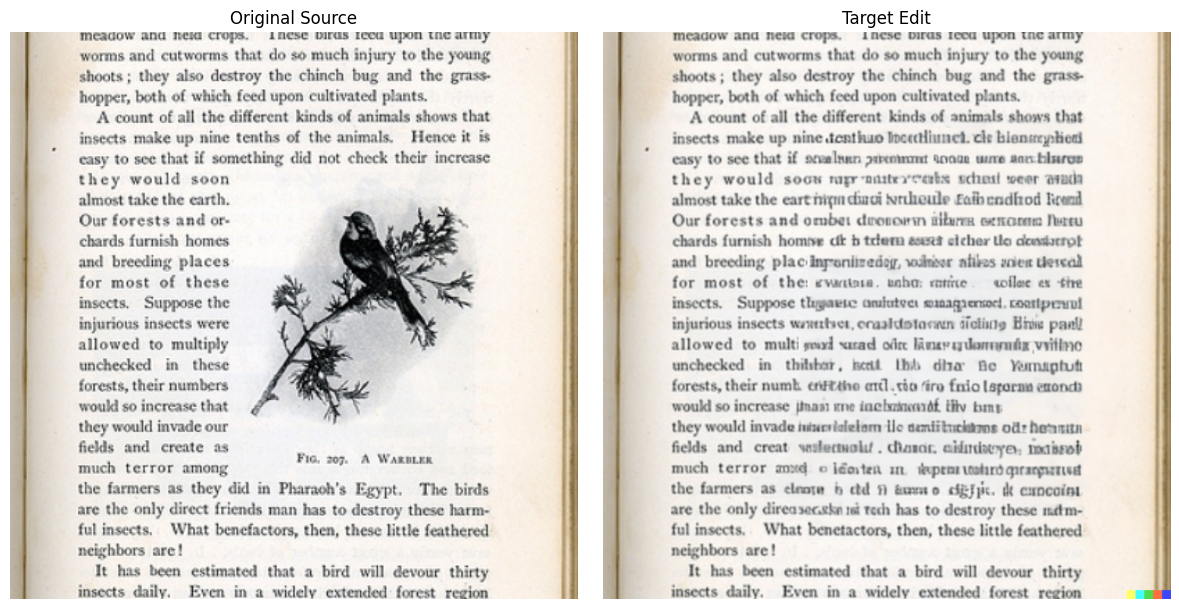

Testing on Index: 3872
Instruction: "leave only words on the page"

--- Model Output ---
{
  "instruction_adherence": "Yes",
  "error_types": [],
  "custom_error": null,
  "reasoning": "The edited image retains all text from the source image, with no changes to the content or layout."
}


In [7]:
# Cell 6: Test the 3B Model with Visualization
import random
import json
import matplotlib.pyplot as plt

# 1. Pick a random example
idx = random.randint(0, len(ds_loaded['train']) - 1)
test_example = ds_loaded['train'][1]

# 2. Visualize the Triplet
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Source Image
axes[0].imshow(test_example['source_img'])
axes[0].set_title("Original Source")
axes[0].axis('off')

# Target Image
axes[1].imshow(test_example['target_img'])
axes[1].set_title("Target Edit")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Testing on Index: {idx}")
print(f"Instruction: \"{test_example['instruction']}\"")

# 3. Run the analysis
# This sends the source image, target image, and instruction to the Qwen model
result, raw_text = analyze_triplet(test_example, model, processor)

# 4. Display the result
print("\n--- Model Output ---")
if result:
    print(json.dumps(result, indent=2))
else:
    print("❌ JSON Parsing Failed. Raw output:")
    print(raw_text)

# **The Main Processing Loop (With Saving)**

In [9]:
# Cell 5: Process Dataset & Save Results
import pandas as pd
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore") # Clean up output

# --- CONFIG ---
OUTPUT_FILE = '/content/drive/MyDrive/ml_project/magicbrush_results_3B.csv'
CHECKPOINT_INTERVAL = 10  # Reduced to 10 for this small test
TARGET_SPLIT = 'train'
STOP_AFTER = 100          # <--- NEW: Stop after the first 100 images

# 1. Setup Resume Logic
results_list = []
processed_ids = set()

if os.path.exists(OUTPUT_FILE):
    print(f"🔄 Found existing results. Resuming...")
    try:
        existing_df = pd.read_csv(OUTPUT_FILE)
        processed_ids = set(existing_df['img_id'].astype(str))
        results_list = existing_df.to_dict('records')
        print(f"   Skipping {len(processed_ids)} already done.")
    except:
        print("   Could not read file. Starting fresh.")
else:
    print("🚀 Starting new analysis.")

# 2. Main Loop
dataset = ds_loaded[TARGET_SPLIT]

for i, example in enumerate(tqdm(dataset)):
    # STOP LOGIC: Break the loop if we reach the limit
    if i >= STOP_AFTER:
        print(f"\n🛑 Reached limit of {STOP_AFTER} images. Stopping test run.")
        break

    img_id = str(example['img_id'])

    # Skip if done
    if img_id in processed_ids:
        continue

    try:
        # Run AI Analysis
        analysis, raw_text = analyze_triplet(example, model, processor)

        if analysis:
            row = {
                'img_id': img_id,
                'instruction': example['instruction'],
                'instruction_adherence': analysis.get('instruction_adherence'),
                'error_types': ", ".join(analysis.get('error_types', [])),
                'custom_error': analysis.get('custom_error'),
                'reasoning': analysis.get('reasoning')
            }
        else:
            # Fallback for failures
            row = {
                'img_id': img_id,
                'instruction': example['instruction'],
                'instruction_adherence': "Error",
                'error_types': "JSON Parse Fail",
                'reasoning': raw_text[:200]
            }

        results_list.append(row)

        # Checkpoint Save
        if len(results_list) % CHECKPOINT_INTERVAL == 0:
            pd.DataFrame(results_list).to_csv(OUTPUT_FILE, index=False)

    except Exception as e:
        print(f"❌ Error at index {i}: {e}")
        continue

# Final Save
pd.DataFrame(results_list).to_csv(OUTPUT_FILE, index=False)
print(f"\n🎉 Test Run Complete! Saved {len(results_list)} rows to: {OUTPUT_FILE}")

🚀 Starting new analysis.


  1%|          | 100/8807 [32:15<46:48:33, 19.35s/it]


🛑 Reached limit of 100 images. Stopping test run.

🎉 Test Run Complete! Saved 100 rows to: /content/drive/MyDrive/ml_project/magicbrush_results_3B.csv
